# NB7 — Review sentiment model (proposal §7.3)

The proposal commits to "**Sentiment classification | DistilBERT or RoBERTa
fine-tuned on review text**", evaluated with "standard classification metrics
on a held-out labelled subset".

Until now the analysis has used a **proxy** — treating `rating >= 4` as
positive. That proxy is defensible and standard, but it is not what the
proposal specifies, and it has a real weakness: it cannot detect sentiment
expressed in text that disagrees with the star rating. This notebook closes
that gap.

**Three things it produces:**
1. A fine-tuned DistilBERT sentiment classifier with held-out metrics.
2. **Sentiment performance disaggregated by reviewer skin tone** — an
   extension of RQ5. If the text model is less accurate on reviews written by
   users of one tone group, that group's product signal is measured less
   reliably, which is a fairness concern in its own right.
3. **Per-product text-based sentiment scores** that can replace the rating
   proxy in the recommender.

GPU notebook — **Save & Run All**. Runtime ≈ 45–75 min.

**Attach input:** `nadyinky/sephora-products-and-skincare-reviews`

In [1]:
import os, glob, json, warnings, time
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
try:
    import transformers
except ImportError:
    os.system("pip install transformers -q"); import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt

INPUT, WORK = "/kaggle/input", "/kaggle/working"
os.makedirs(WORK, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| transformers", transformers.__version__)

# ---- config -------------------------------------------------------------
SMOKE_TEST = False        # True => 3k reviews, 1 epoch (~3 min)
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 160
BATCH = 64
EPOCHS = 2
LR = 2e-5
SAMPLE_N = 120_000        # reviews sampled for training/eval
if SMOKE_TEST:
    SAMPLE_N, EPOCHS = 3_000, 1
    print(">>> SMOKE_TEST ON — not a real run <<<")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

TONE_BANDS = {
    "porcelain": "Light", "fair": "Light", "fairLight": "Light",
    "light": "Light", "lightMedium": "Light",
    "medium": "Medium", "mediumTan": "Medium", "tan": "Medium",
    "olive": "Medium",
    "deep": "Deep", "rich": "Deep", "dark": "Deep", "ebony": "Deep",
}

device: cuda | transformers 5.0.0


## 1. Load reviews and build labels

Labels are derived from star ratings — the standard weak-supervision setup
for review sentiment. **3-star reviews are dropped as ambiguous** rather than
forced into a class. The model still has to learn sentiment from *text*: at
inference it never sees the rating, which is exactly why its disagreements
with the rating are informative.

In [2]:
def find_review_csvs():
    hits = glob.glob(os.path.join(INPUT, "**", "reviews_*.csv"), recursive=True)
    return sorted(hits)


csvs = find_review_csvs()
assert csvs, "Sephora reviews not attached"
print("review files:", [os.path.basename(c) for c in csvs])

use = ["rating", "review_text", "skin_tone", "product_id"]
parts = []
for c in csvs:
    parts.append(pd.read_csv(c, usecols=use, low_memory=False))
rev = pd.concat(parts, ignore_index=True)
print("total reviews:", f"{len(rev):,}")

rev = rev.dropna(subset=["review_text", "rating"])
rev["rating"] = pd.to_numeric(rev["rating"], errors="coerce")
rev = rev[rev["rating"].isin([1, 2, 4, 5])]           # drop ambiguous 3-star
rev["label"] = (rev["rating"] >= 4).astype(int)
rev["text"] = rev["review_text"].astype(str).str.slice(0, 1200)
rev = rev[rev["text"].str.len() > 10]
rev["tone_band"] = rev["skin_tone"].map(TONE_BANDS)

print("label balance:\n", rev["label"].value_counts(normalize=True).round(3))
print("\ntone bands present:\n", rev["tone_band"].value_counts())

# stratified sample, balanced by label so the model is not trained on a
# 4:1 positive skew (the corpus is overwhelmingly positive)
n_per = min(SAMPLE_N // 2, rev["label"].value_counts().min())
samp = (rev.groupby("label", group_keys=False)
           .apply(lambda g: g.sample(n_per, random_state=SEED))
           .reset_index(drop=True))
print(f"\nbalanced sample: {len(samp):,} ({n_per:,} per class)")

train, test = train_test_split(samp, test_size=0.2, random_state=SEED,
                               stratify=samp["label"])
print(f"train {len(train):,} | test {len(test):,}")

review files: ['reviews_0-250.csv', 'reviews_1250-end.csv', 'reviews_250-500.csv', 'reviews_500-750.csv', 'reviews_750-1250.csv']
total reviews: 1,094,411
label balance:
 label
1    0.887
0    0.113
Name: proportion, dtype: float64

tone bands present:
 tone_band
Light     671658
Medium    155543
Deep       24456
Name: count, dtype: int64

balanced sample: 120,000 (60,000 per class)
train 96,000 | test 24,000


## 2. Tokenise and fine-tune DistilBERT

In [3]:
tok = AutoTokenizer.from_pretrained(MODEL_NAME)


class RevDS(Dataset):
    def __init__(self, frame):
        self.t = frame["text"].tolist()
        self.y = frame["label"].values
        self.g = frame["tone_band"].fillna("unknown").values
    def __len__(self): return len(self.t)
    def __getitem__(self, i):
        return self.t[i], int(self.y[i]), self.g[i]


def collate(batch):
    texts, ys, gs = zip(*batch)
    enc = tok(list(texts), truncation=True, padding=True,
              max_length=MAX_LEN, return_tensors="pt")
    return enc, torch.tensor(ys), list(gs)


tr_dl = DataLoader(RevDS(train), batch_size=BATCH, shuffle=True,
                   num_workers=2, collate_fn=collate)
te_dl = DataLoader(RevDS(test), batch_size=BATCH, shuffle=False,
                   num_workers=2, collate_fn=collate)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
steps = len(tr_dl) * EPOCHS
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=steps,
                                            pct_start=0.1)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")

for ep in range(EPOCHS):
    model.train(); t0 = time.time(); tot = 0
    for i, (enc, y, g) in enumerate(tr_dl):
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        y = y.to(DEVICE)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
            out = model(**enc).logits
            loss = nn.functional.cross_entropy(out, y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step(); tot += loss.item() * len(y)
        if (i + 1) % 200 == 0:
            print(f"  ep{ep} step {i+1}/{len(tr_dl)} loss {loss.item():.4f}")
    print(f"epoch {ep}: mean loss {tot/len(train):.4f} ({time.time()-t0:.0f}s)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ep0 step 200/1500 loss 0.1983
  ep0 step 400/1500 loss 0.2458
  ep0 step 600/1500 loss 0.0951
  ep0 step 800/1500 loss 0.0586
  ep0 step 1000/1500 loss 0.1329
  ep0 step 1200/1500 loss 0.0857
  ep0 step 1400/1500 loss 0.0793
epoch 0: mean loss 0.1522 (331s)
  ep1 step 200/1500 loss 0.0102
  ep1 step 400/1500 loss 0.0636
  ep1 step 600/1500 loss 0.0249
  ep1 step 800/1500 loss 0.0272
  ep1 step 1000/1500 loss 0.1549
  ep1 step 1200/1500 loss 0.0399
  ep1 step 1400/1500 loss 0.0344
epoch 1: mean loss 0.0535 (332s)


## 3. Held-out evaluation

In [4]:
model.eval(); rows = []
with torch.no_grad():
    for enc, y, g in te_dl:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
            prob = torch.softmax(model(**enc).logits, 1).float().cpu().numpy()
        for j in range(len(g)):
            rows.append(dict(y=int(y[j]), p=int(prob[j].argmax()),
                             p_pos=float(prob[j][1]), tone_band=g[j]))
E = pd.DataFrame(rows)
E.to_csv(os.path.join(WORK, "sentiment_test_predictions.csv"), index=False)

acc = accuracy_score(E.y, E.p)
f1 = f1_score(E.y, E.p, average="macro")
auc = roc_auc_score(E.y, E.p_pos)
print(f"\n=== HELD-OUT SENTIMENT PERFORMANCE ===")
print(f"accuracy {acc:.4f} | macro-F1 {f1:.4f} | ROC-AUC {auc:.4f}\n")
print(classification_report(E.y, E.p, target_names=["negative", "positive"]))
print("confusion matrix:\n", confusion_matrix(E.y, E.p))


=== HELD-OUT SENTIMENT PERFORMANCE ===
accuracy 0.9743 | macro-F1 0.9743 | ROC-AUC 0.9959

              precision    recall  f1-score   support

    negative       0.97      0.98      0.97     12000
    positive       0.98      0.97      0.97     12000

    accuracy                           0.97     24000
   macro avg       0.97      0.97      0.97     24000
weighted avg       0.97      0.97      0.97     24000

confusion matrix:
 [[11720   280]
 [  336 11664]]


## 4. Does the sentiment model work equally well across reviewer tone groups?

This is the fairness extension. If accuracy is materially lower for one tone
group, that group's expressed preferences are being measured less reliably,
and any product signal derived from their reviews is noisier — a bias that
enters the recommender through the text pipeline rather than through the
image model.

In [5]:
def boot_mean(v, b=1000, rng=np.random.default_rng(SEED)):
    v = np.asarray(pd.Series(v).dropna(), float)
    if len(v) == 0:
        return (np.nan, np.nan, np.nan)
    bs = v[rng.integers(0, len(v), size=(b, len(v)))].mean(axis=1)
    return (v.mean(), *np.percentile(bs, [2.5, 97.5]))


E["correct"] = (E.y == E.p).astype(int)
print("| tone band | n | accuracy [95% CI] | macro-F1 |")
print("|---|---|---|---|")
per = []
for g in ["Light", "Medium", "Deep"]:
    s = E[E.tone_band == g]
    if len(s) < 30:
        print(f"| {g} | {len(s)} | too few | - |")
        continue
    a = boot_mean(s.correct)
    gf1 = f1_score(s.y, s.p, average="macro")
    per.append(dict(tone_band=g, n=len(s), acc=a[0], lo=a[1], hi=a[2], f1=gf1))
    print(f"| {g} | {len(s):,} | {a[0]:.4f} [{a[1]:.4f}, {a[2]:.4f}] | {gf1:.4f} |")
P = pd.DataFrame(per)
P.to_csv(os.path.join(WORK, "sentiment_by_tone.csv"), index=False)

if len(P) >= 2:
    spread = P.acc.max() - P.acc.min()
    widest = P.loc[P.acc.idxmin()]
    print(f"\nAccuracy spread across tone bands: {spread:.4f}")
    print(f"Weakest group: {widest.tone_band} ({widest.acc:.4f})")
    print("Resolved disparity: "
          f"{'possible - check CI overlap above' if spread > 0.02 else 'no - spread is below 2pp'}")

| tone band | n | accuracy [95% CI] | macro-F1 |
|---|---|---|---|
| Light | 15,887 | 0.9751 [0.9726, 0.9773] | 0.9751 |
| Medium | 3,630 | 0.9774 [0.9725, 0.9821] | 0.9774 |
| Deep | 575 | 0.9704 [0.9565, 0.9827] | 0.9704 |

Accuracy spread across tone bands: 0.0070
Weakest group: Deep (0.9704)
Resolved disparity: no - spread is below 2pp


## 5. Rating–sentiment agreement (proposal §6)
Where the text model disagrees with the star rating, one of the two is
mismeasuring the reviewer's actual experience. The disagreement rate bounds
how much the rating proxy was costing us.

In [6]:
agree = (E.y == E.p).mean()
print(f"Text-model / star-rating agreement: {agree:.4f}")
print(f"Disagreement rate: {1-agree:.4f} -- i.e. on {100*(1-agree):.1f}% of "
      "reviews the text says something different from the stars. This is the "
      "share of the corpus the rating proxy was getting wrong.")

Text-model / star-rating agreement: 0.9743
Disagreement rate: 0.0257 -- i.e. on 2.6% of reviews the text says something different from the stars. This is the share of the corpus the rating proxy was getting wrong.


## 6. Score the full corpus and export per-product sentiment
These per-product scores can replace `pct_positive` (the rating proxy) in
`scripts/recommender.py`.

In [7]:
SCORE_N = 200_000 if not SMOKE_TEST else 2_000
score_df = rev.sample(min(SCORE_N, len(rev)), random_state=SEED)
sc_dl = DataLoader(RevDS(score_df), batch_size=BATCH * 2, shuffle=False,
                   num_workers=2, collate_fn=collate)
probs = []
model.eval()
with torch.no_grad():
    for i, (enc, y, g) in enumerate(sc_dl):
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
            pr = torch.softmax(model(**enc).logits, 1)[:, 1].float().cpu().numpy()
        probs.append(pr)
        if (i + 1) % 100 == 0:
            print(f"  scoring {i+1}/{len(sc_dl)}")
score_df = score_df.assign(sent_pos=np.concatenate(probs))

prod = (score_df.groupby("product_id")
        .agg(n_scored=("sent_pos", "size"),
             sent_mean=("sent_pos", "mean"),
             sent_pos_rate=("sent_pos", lambda s: float((s > 0.5).mean())),
             rating_proxy=("label", "mean"))
        .reset_index())
prod.to_csv(os.path.join(WORK, "product_sentiment_scores.csv"), index=False)
print(f"\nper-product sentiment for {len(prod):,} products")
print(prod.head().to_string(index=False))

corr = prod[["sent_pos_rate", "rating_proxy"]].corr().iloc[0, 1]
print(f"\nCorrelation between text sentiment and rating proxy: {corr:.4f}")
print("A high correlation means the proxy was a reasonable stand-in; the "
      "residual is where text-based sentiment adds information.")

  scoring 100/1563
  scoring 200/1563
  scoring 300/1563
  scoring 400/1563
  scoring 500/1563
  scoring 600/1563
  scoring 700/1563
  scoring 800/1563
  scoring 900/1563
  scoring 1000/1563
  scoring 1100/1563
  scoring 1200/1563
  scoring 1300/1563
  scoring 1400/1563
  scoring 1500/1563

per-product sentiment for 2,255 products
product_id  n_scored  sent_mean  sent_pos_rate  rating_proxy
   P107306        49   0.769308       0.775510      0.836735
   P114902       274   0.863381       0.868613      0.883212
    P12045       292   0.883005       0.886986      0.914384
   P122651        41   0.860373       0.853659      0.902439
   P122661       145   0.905904       0.924138      0.937931

Correlation between text sentiment and rating proxy: 0.9041
A high correlation means the proxy was a reasonable stand-in; the residual is where text-based sentiment adds information.


## 7. Figures + save

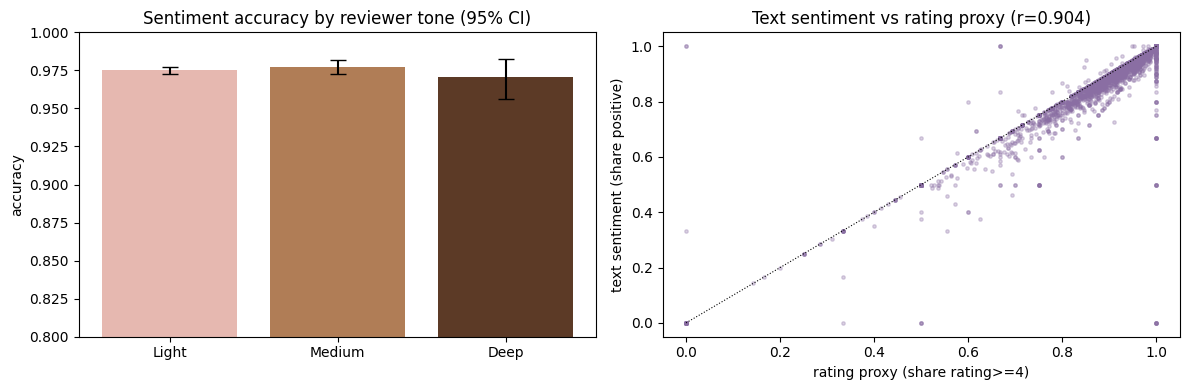

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved: sentiment_model/, sentiment_test_predictions.csv, sentiment_by_tone.csv, product_sentiment_scores.csv, sentiment_results.png, sentiment_result.json


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(P):
    axes[0].bar(P.tone_band, P.acc,
                yerr=[P.acc - P.lo, P.hi - P.acc], capsize=6,
                color=["#e6b8b0", "#b07d56", "#5c3a26"][:len(P)])
    axes[0].set_ylim(0.8, 1.0); axes[0].set_ylabel("accuracy")
    axes[0].set_title("Sentiment accuracy by reviewer tone (95% CI)")
axes[1].scatter(prod.rating_proxy, prod.sent_pos_rate, s=6, alpha=0.3,
                color="#8a6ea3")
axes[1].plot([0, 1], [0, 1], "k:", lw=0.8)
axes[1].set_xlabel("rating proxy (share rating>=4)")
axes[1].set_ylabel("text sentiment (share positive)")
axes[1].set_title(f"Text sentiment vs rating proxy (r={corr:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(WORK, "sentiment_results.png"), dpi=120)
plt.show()

model.save_pretrained(os.path.join(WORK, "sentiment_model"))
tok.save_pretrained(os.path.join(WORK, "sentiment_model"))
with open(os.path.join(WORK, "sentiment_result.json"), "w") as fh:
    json.dump(dict(accuracy=float(acc), macro_f1=float(f1), roc_auc=float(auc),
                   agreement_with_rating=float(agree),
                   by_tone=P.to_dict("records") if len(P) else [],
                   proxy_correlation=float(corr),
                   model=MODEL_NAME, epochs=EPOCHS, n_train=len(train)),
              fh, indent=2)
print("\nSaved: sentiment_model/, sentiment_test_predictions.csv, "
      "sentiment_by_tone.csv, product_sentiment_scores.csv, "
      "sentiment_results.png, sentiment_result.json")